In [4]:
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import jax
import pytest

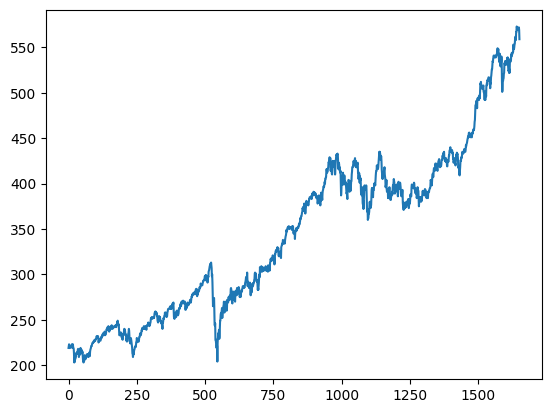

In [19]:
data = pd.read_csv('../data/historicalData_IE00B5BMR087_clean.csv')
# Add the Returns column as soon as the data is loaded
data['Returns'] = ((data['Last Close'] - data['Open']) / data['Open'])

# Plot closing price as graph
plt.plot(data['Last Close'])

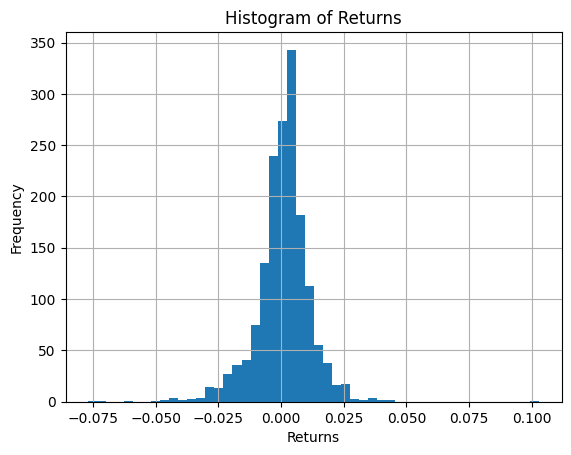

Average return:  0.0006308976407192723
Winning days:  801
Losing days:  599


In [20]:
# Plot returns as histogram
returns = data['Last Close'].pct_change()
returns.hist(bins=50)
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.title('Histogram of Returns')
plt.show()

# Print average return
print('Average return: ', np.mean(returns))

# Print winning days
winning_days = returns[returns > 0]
print('Winning days: ', len(winning_days))

# Print losing days
losing_days = returns[returns < 0]
print('Losing days: ', len(losing_days))

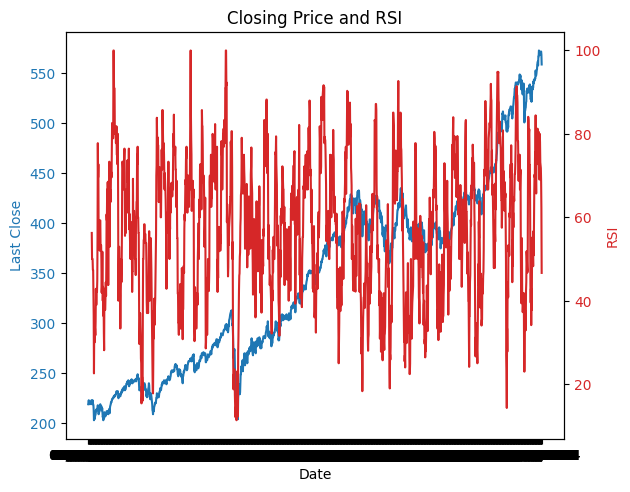

Percentage of winning days where the RSI is above average: 57.30%


In [21]:
def calculate_rsi(data, window=14):
    delta = data['Last Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

data['RSI'] = calculate_rsi(data)

# Plot closing price and RSI
fig, ax1 = plt.subplots()

ax1.set_xlabel('Date')
ax1.set_ylabel('Last Close', color='tab:blue')
ax1.plot(data['Date'], data['Last Close'], color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('RSI', color='tab:red')
ax2.plot(data['Date'], data['RSI'], color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()
plt.title('Closing Price and RSI')
plt.show()

# Print the % of winning days where the RSI is above average
average_rsi = data['RSI'].mean()
winning_days_above_avg_rsi = winning_days[data.loc[winning_days.index, 'RSI'] > average_rsi]
percentage_winning_days_above_avg_rsi = (len(winning_days_above_avg_rsi) / len(winning_days)) * 100
print(f'Percentage of winning days where the RSI is above average: {percentage_winning_days_above_avg_rsi:.2f}%')


In [ ]:
# Define short-term and long-term moving averages
short_window = 40
long_window = 100

# Calculate moving averages
data['Short_MA'] = data['Last Close'].rolling(window=short_window, min_periods=1).mean()
data['Long_MA'] = data['Last Close'].rolling(window=long_window, min_periods=1).mean()

# Identify uptrends and downtrends
data['Trend'] = np.where(data['Short_MA'] > data['Long_MA'], 'Uptrend', 'Downtrend')

# Filter winning days within an uptrend
winning_days_uptrend = winning_days[data.loc[winning_days.index, 'Trend'] == 'Uptrend']

# Calculate the percentage of winning days within an uptrend
percentage_winning_days_uptrend = (len(winning_days_uptrend) / len(winning_days)) * 100
print(f'Percentage of winning days within an uptrend: {percentage_winning_days_uptrend:.2f}%')

Percentage of winning days within an uptrend: 74.66%


In [32]:
import pandas as pd

# Load data and parse dates
data = pd.read_csv('../data/historicalData_IE00B5BMR087_clean.csv', parse_dates=['Date'])

# Sort by Date column
data.sort_values('Date', inplace=True)

# Set the Date as index
data.set_index('Date', inplace=True)

# Now we have a proper DatetimeIndex, we can safely apply asfreq()
data = data.asfreq('B')  # Business days frequency

print(data.head())
print(data.tail())

print("First date:", data.index.min())
print("Last date:", data.index.max())

# Suppose we want to split at '2024-09-30'
cutoff_date = '2024-09-30'

# Check if cutoff date exists
if cutoff_date in data.index:
    train_end = cutoff_date
else:
    # Find the last available date before or on the cutoff
    possible_dates = data.index[data.index <= cutoff_date]
    if len(possible_dates) > 0:
        train_end = possible_dates[-1]
    else:
        # If no date <= cutoff_date exists, just use the last available date in data
        train_end = data.index[-1]

trainD = data.loc[:train_end]
testD = data.loc[train_end:]  # This includes train_end, use `data.loc[data.index > train_end]` if needed.

print("Train set last date:", trainD.index.max())
print("Test set first date:", testD.index.min())

             Open   High    Low  Last Close
Date                                       
2018-01-05  219.0  219.0  219.0       219.0
2018-01-08  221.0  221.0  221.0       221.0
2018-01-09  223.0  223.0  223.0       223.0
2018-01-10  221.0  221.0  221.0       221.0
2018-01-11  220.0  220.0  220.0       220.0
             Open   High    Low  Last Close
Date                                       
2024-10-25  569.0  571.0  569.0       571.0
2024-10-28  572.0  572.0  571.0       571.0
2024-10-29  573.0  573.0  570.0       572.0
2024-10-30  573.0  573.0  569.0       569.0
2024-10-31  573.0  573.0  559.0       559.0
First date: 2018-01-05 00:00:00
Last date: 2024-10-31 00:00:00
Train set last date: 2024-09-30 00:00:00
Test set first date: 2024-09-30 00:00:00
